## SITCOM-2049



In [5]:
#Setting packages
import asyncio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import seaborn as sns
import datetime as dt
from scipy import stats
import matplotlib.dates
from matplotlib.dates import DateFormatter
#from astropy.table import Table, join
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from lsst.utils.packages import getEnvironmentPackages
#%matplotlib widget

from astropy.time import Time, TimeDelta
from lsst_efd_client.efd_helper import merge_packed_time_series
from lsst.meas.algorithms.installGaussianPsf import FwhmPerSigma
from lsst.daf.butler import Butler 
#from tqdm.notebook import tqdm

# Ignore the many warning messages from ``merge_packed_time_series``
warnings.simplefilter(action="ignore", category=FutureWarning)

#-------Clients
from lsst_efd_client import EfdClient
client = EfdClient("usdf_efd")
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)

#from lsst.summit.utils.efdUtils import makeEfdClient
#client = makeEfdClient()

#from lsst.summit.utils import ConsDbClient
#os.environ["no_proxy"] += ",.consdb"
#url="http://consdb-pq.consdb:8080/consdb"
#consdb=ConsDbClient(url)
#-------Clients



In [2]:
### function 

def float_hours(h,m,s,ms):
    f = (h * 3600 +
    m * 60 +
    s +
    ms / 1e6) /3600

    return f

In [3]:
#Initialize an EFD client
efd_client = makeEfdClient()

In [48]:
#Observation time
## We go a month in time -- could go largher 
start_time = Time("2026-03-01T00:00:00Z", scale="utc")
end_time = Time("2026-03-24T23:59:00Z", scale="utc")

In [49]:
start_time.strftime('%Y-%m-%d')

'2026-03-01'

In [50]:
## pullling a subset of columns from the EFD 
df_script = getEfdData(
             client=efd_client,
             topic="lsst.sal.ScriptQueue.logevent_script",
             #columns=["*"],         
    columns=["cmdId","salIndex","path","scriptState", "scriptSalIndex","processState","timestampProcessStart", "timestampConfigureStart", "timestampConfigureEnd", "timestampRunStart" ],
             begin=start_time,
             end=end_time,
)

In [39]:
# filter: MTQ and selecting entries for a common cmdId

df_filt=df_script[(df_script['salIndex']==1)].groupby('cmdId').tail(1) ## 

### NOTEs: 
#### 1. Script SAL ids are NOT unique because they get recycled every time the scriptQ gets restarted (no cadence of this!) 
#### 2. When a script is terminated-- it turns that the delta_t (i.e total time between configure start to end ) goes -1.7e-9. That is becaise there is NO timestanp for ConfigureEnd 

In [51]:
#df_filt['configure_start']=pd.to_datetime(df_filt['timestampConfigureStart'], unit='s')
#df_filt['configure_end']=pd.to_datetime(df_filt['timestampConfigureEnd'], unit='s')
df_filt['tdelta_config']= (df_filt['timestampConfigureEnd']-df_filt['timestampConfigureStart'])
df_filt['weekday']=df_filt.index.day_name() ## extarcting week day from the datetime object 
df_filt['tod']= float_hours(df_filt.index.hour,df_filt.index.minute,df_filt.index.second, df_filt.index.microsecond)# extracting time from the date-time index 
df_filt['month']=df_filt.index.month_name() ## extracting week day from the datetime object 

## data checks 

In [42]:
#### A lot of scripts showed delta_t 

In [ ]:
#print(min(df_filt[df_filt['tdelta_12']<0]['processState']))

In [52]:
#df_filt['tod'].dtype

dtype('float64')

## Latency time analysis 

#### the maximum latency observed in this time period is a 1 min & min is 0 (sounds a bit impractical!); average is about 9 secs 

In [53]:
df =df_filt[df_filt['tdelta_config']>=0]

## Monthly lookout: Time Series analysis Weekday vs Hour of the day and the configure latency 

#### This plot gives a monthly look at how quickly the scripts got configured. Ideally, they should get configured as soon as loaded (i.e. 0 s) but that is impractical. We will define a relaxed 5% of a minute as the threshold for requirement of rapid script configuration time. 
#### 1. the ideal average script config time should be <= 5% of a minute i.e. <= 3s 
#### 2. typical NO begins from 22:00 UTC to 09:30 + 1 UTC. As such, 

#### Scripts with longest config times --- its not helpful without weekday seasonality 

In [55]:
df.nlargest(10, 'tdelta_config') ## gives top 10 scripts with longest config times-- these are mostly  non-scheduler scripts. 

,cmdId,salIndex,path,scriptState,scriptSalIndex,processState,timestampProcessStart,timestampConfigureStart,timestampConfigureEnd,timestampRunStart,tdelta_config,weekday,tod,month
2025-12-02 07:33:03.283305+00:00,132255422,1,maintel/mtdome/enable_dome_following.py,2,100420,6,1.764661e+09,1.764661e+09,1.764661e+09,0.0,60.003451,Tuesday,7.550912,December
2025-12-01 05:21:14.452388+00:00,132255264,1,maintel/mtdome/disable_dome_following.py,2,101735,6,1.764566e+09,1.764566e+09,1.764566e+09,0.0,60.002312,Monday,5.354015,December
2025-12-31 08:29:07.937580+00:00,45892597,1,maintel/mtdome/park_dome.py,2,106903,6,1.767169e+09,1.767169e+09,1.767169e+09,0.0,60.002213,Wednesday,8.485538,December
2025-12-01 08:05:01.461711+00:00,132255285,1,maintel/mtdome/disable_dome_following.py,2,101759,6,1.764576e+09,1.764576e+09,1.764576e+09,0.0,60.002208,Monday,8.083739,December
2025-12-01 08:04:18.848076+00:00,132255284,1,maintel/mtdome/disable_dome_following.py,2,101758,6,1.764576e+09,1.764576e+09,1.764576e+09,0.0,60.002114,Monday,8.071902,December
2025-12-02 07:30:17.370573+00:00,132255421,1,maintel/mtdome/enable_dome_following.py,2,100417,6,1.764661e+09,1.764661e+09,1.764661e+09,0.0,60.002050,Tuesday,7.504825,December
2025-12-15 05:01:57.831806+00:00,8037616,1,maintel/disable_aos_closed_loop.py,1,103723,6,1.765775e+09,1.765775e+09,1.765775e+09,0.0,60.002016,Monday,5.032731,December
2025-12-01 08:15:58.939568+00:00,132255293,1,maintel/mtdome/park_dome.py,2,101767,6,1.764577e+09,1.764577e+09,1.764577e+09,0.0,60.001953,Monday,8.266372,December
2025-12-25 03:58:12.725430+00:00,51391743,1,maintel/enable_aos_closed_loop.py,1,105749,6,1.766635e+09,1.766635e+09,1.766635e+09,0.0,60.001786,Thursday,3.970202,December
2025-12-17 08:03:44.875432+00:00,114788563,1,maintel/enable_aos_closed_loop.py,1,100411,6,1.765958e+09,1.765958e+09,1.765958e+09,0.0,60.001696,Wednesday,8.062465,December


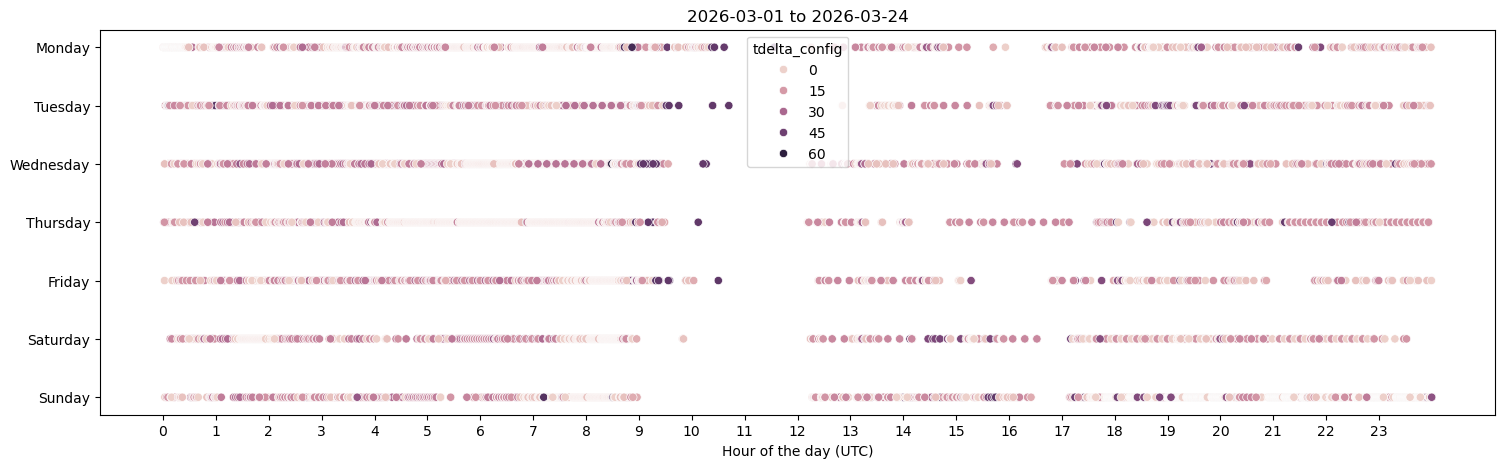

Average script configuring time: 11.316017848810809
Longest script config delay: 60.003451108932495


In [56]:


plt.figure(figsize=(18, 5))
#plt.scatter(x=df['tod'].values.astype(str), y=df['weekday'])
sns.scatterplot(data= df, x=df['tod'] , y=df['weekday'].values.astype(str), hue=df['tdelta_config'] )
#plt.plot(df['tod'].values.astype(str)  ,df['weekday'].values.astype(str) )
plt.xticks(np.arange(0,24,1))
plt.title(start_time.strftime('%Y-%m-%d')+' to '+end_time.strftime('%Y-%m-%d'))
plt.xlabel("Hour of the day (UTC)")
#plt.savefig('scriptconfig-times-monthly'+max(df['month'])+'.png')
plt.show()

print("Average script configuring time:", str(np.mean(df['tdelta_config'])))
print("Longest script config delay:", str(max(df['tdelta_config'])))

In [10]:
print(np.__version__)

2.4.3
